In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
figsfolder="./figscode"

In [3]:
def getPs(pars,x):
    Kx,Kp,w=pars
    
    Z=1+Kx*x+Kp+Kx*Kp*w*x
    P1=1/Z
    P2=Kx*x/Z
    P3=Kp/Z
    P4=Kx*x*Kp*w/Z
    
    return np.array([P1,P2,P3,P4])

def plot_parset(pars,qs,title=None,widerange=False,color="k",figname=None,returnonly=False):
    q3,q4=qs
    if not widerange:
        xvals=np.logspace(-1.,1.,200)
    else:
        xvals=np.logspace(-3,3,1000)
    values=np.zeros(len(xvals))
    xval=0
    Ps=getPs(pars,xval)
    expr0=q3*Ps[2]+q4*Ps[3]
    

    for x_,xval in enumerate(xvals):
        
        Ps=getPs(pars,xval)
        expr=q3*Ps[2]+q4*Ps[3]
        values[x_]=expr/expr0
    if not returnonly:
        fig,ax=plt.subplots(1,1,figsize=(1.5,1))
        ax.plot(xvals,values,color=color)
        ax.set_xscale('log')
        ax.set_xlabel(r"$x$",size=14)
        ax.set_ylabel('fold change ($F(x)$)',size=12)
        ax.axhline(y=1,linestyle="--",color="gray")
        if title is not None:
            ax.set_title(title)
        plt.tight_layout()
        if figname is not None:
            plt.savefig(figname,bbox_inches="tight")
        plt.show()
    else:
        return values
        
        

<ipython-input-3-0091b9822ca8>:38: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


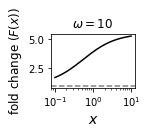

In [4]:
w=10
Kx=1
Kp=0.1
pars=[Kx,Kp,w]
qs=[1,1]
title=r"$\omega=%g$"%(w)
plot_parset(pars,qs,title=title,figname=os.path.join(figsfolder,"Fig1up.pdf"))

<ipython-input-3-0091b9822ca8>:38: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


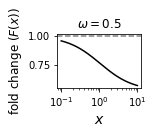

In [5]:
w=0.5
pars=[Kx,Kp,w]
qs=[1,1]
title=r"$\omega=%g$"%(w)
plot_parset(pars,qs,title=title,figname=os.path.join(figsfolder,"Fig1down.pdf"))